In [1]:
import scanpy as sc
import decoupler as dc
import seaborn as sns
import matplotlib.pyplot as plt

/data/hu367653/.conda/envs/new_NicheSphere_env/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
adata_singlets=sc.read('../data/PICseq/final_data/adata_singlets_final.h5ad')

In [3]:
adata_doublets=sc.read('../data/PICseq/final_data/adata_doublets_final.h5ad')

In [4]:
#niche_names=['1_Resident_myeloid_niche', '2_FibCore', '3_Macrophage_vascular_niche', '4_Fibro_myeloid_niche']


In [5]:
niches_dict={'1_Resident_myeloid_niche': ['Neut2', 'ResMac', 'DC', 'Baso'],
 '2_FibCore': ['Ery', 'TCells', 'Spp1+Mac', 'OsteoCAR', 'MK'],
 '3_Macrophage_vascular_niche': ['InfiltMac', 'EC', 'Ly6ClowMac'],
 '4_Fibro_myeloid_niche': ['Fibro', 'MonoPro', 'Neut1', 'BCells']}

In [6]:
adata_singlets.obs['niche']='1_Resident_myeloid_niche'
adata_singlets.obs['niche'][[i in niches_dict['2_FibCore'] for i in adata_singlets.obs.annotation]]='2_FibCore'
adata_singlets.obs['niche'][[i in niches_dict['3_Macrophage_vascular_niche'] for i in adata_singlets.obs.annotation]]='3_Macrophage_vascular_niche'
adata_singlets.obs['niche'][[i in niches_dict['4_Fibro_myeloid_niche'] for i in adata_singlets.obs.annotation]]='4_Fibro_myeloid_niche'


/tmp/ipykernel_1787996/2748578640.py:2: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  adata_singlets.obs['niche'][[i in niches_dict['2_FibCore'] for i in adata_singlets.obs.annotation]]='2_FibCore'
/tmp/ipykernel_1787996/2748578640.py:2: Set

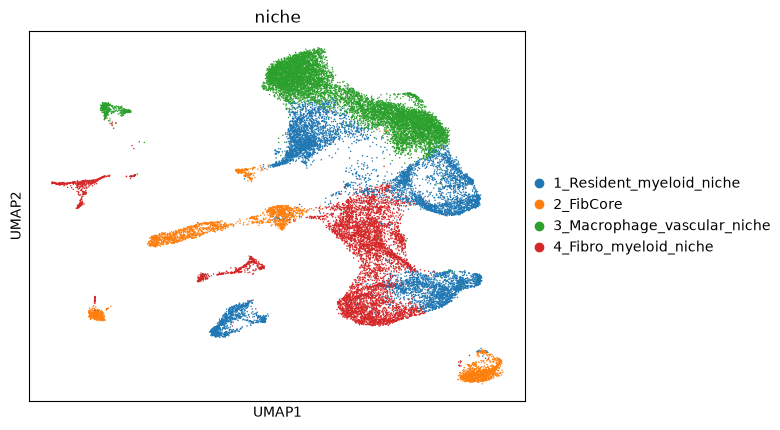

In [7]:
adata_singlets.obsm['X_umap']=adata_singlets.obsm['X_harmony_umap']
sc.pl.umap(adata_singlets, color='niche')


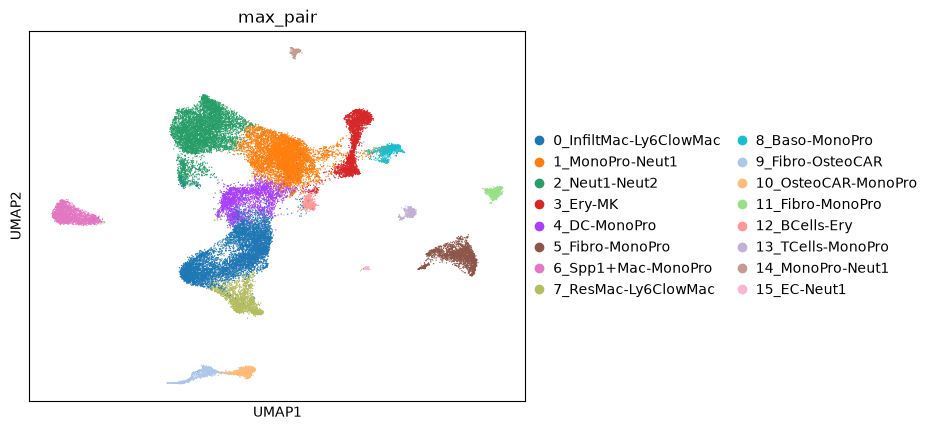

In [8]:
sc.pl.umap(adata_doublets, color='max_pair')

In [9]:
progeny = dc.op.progeny(organism='mouse', top=500)
progeny.head()

,source,target,weight,padj
0,Androgen,Tmprss2,11.490631,2.384806e-47
1,Androgen,Nkx3-1,10.622551,2.205102e-44
2,Androgen,Mboat2,10.472733,4.632376e-44
3,Androgen,Slc38a4,7.363805,1.253071e-39
4,Androgen,Mtmr9,6.130646,2.534403e-38


In [10]:
dc.mt.mlm(
    data=adata_doublets,
    net=progeny, 
    verbose=True
)

2026-07-24 12:11:37 | [INFO] mlm - Running mlm
2026-07-24 12:11:37 | [INFO] Extracted omics mat with 35927 rows (observations) and 20664 columns (features)
2026-07-24 12:11:38 | [INFO] Network adjacency matrix has 4387 unique features and 14 unique sources
100%|██████████| 1/1 [00:24<00:00, 24.92s/it]
2026-07-24 12:12:03 | [INFO] mlm - done


In [11]:
adata_doublets.obsm['score_mlm'].head()

,Androgen,EGFR,Estrogen,Hypoxia,JAK-STAT,MAPK,NFkB,PI3K,TGFb,TNFa,Trail,VEGF,WNT,p53
IS3_AAACCCAAGAGTCAGC-1,-0.042131,1.347258,-0.271764,0.150133,0.757080,-1.727555,-2.763108,-0.446864,-1.288316,2.574423,-1.416986,0.460340,0.274917,-7.519040
IS3_AAACCCAAGGGCTGAT-1,2.260181,-0.224176,-1.062120,0.754524,1.955312,-1.653949,-0.626371,-1.782119,0.010720,1.579380,0.350257,-0.061927,1.721196,-3.628299
IS3_AAACCCACACGCCAGT-1,0.912010,1.045548,0.127042,2.046216,2.812260,-2.948112,-2.897045,-0.071129,-1.465579,2.588782,-0.873733,0.553206,0.197502,-9.188521
IS3_AAACCCACACTACCGG-1,0.020182,-0.364666,1.129167,1.424952,-0.534943,-1.305770,-2.508734,1.347094,-1.619001,2.107474,-0.988237,0.219569,-0.504480,-5.565535
IS3_AAACCCACAGATCCTA-1,-0.544810,1.595849,-1.531775,-0.080158,2.112333,-1.615051,-1.676308,-0.573626,-1.356999,2.056233,0.004170,0.184380,-0.002802,-2.962016


In [12]:
adata_doublets.obsm['progeny_mlm_estimate'] = adata_doublets.obsm['score_mlm'].copy()
adata_doublets.obsm['progeny_mlm_pvals'] = adata_doublets.obsm['padj_mlm'].copy()

In [13]:
acts = dc.pp.get_obsm(adata_doublets, key="score_mlm")
acts

AnnData object with n_obs × n_vars = 35927 × 14
    obs: 'nCount_RNA', 'nFeature_RNA', 'name', 'stage', 'percent.mt', 'percent.ribo', 'nCount_decontX', 'nFeature_decontX', 'AmbientRNA', 'decontX_clusters', 'Doublet_classifications', 'percent.exclude', 'S.Score', 'G2M.Score', 'Phase', 'G1.Score', 'CC.Difference', 'integrated_snn_res.0.1', 'integrated_snn_res.0.2', 'integrated_snn_res.0.3', 'integrated_snn_res.0.4', 'integrated_snn_res.0.5', 'integrated_snn_res.0.6', 'integrated_snn_res.0.7', 'integrated_snn_res.0.8', 'seurat_clusters', 'RNA_snn_res.0.1', 'RNA_snn_res.0.2', 'RNA_snn_res.0.3', 'RNA_snn_res.0.4', 'RNA_snn_res.0.5', 'RNA_snn_res.0.6', 'RNA_snn_res.0.7', 'RNA_snn_res.0.8', 'seurat_inte_clusters', 'harmony_inte_clusters', 'MCA_annotate', 'external_annotation', 'HCL_annotate', 'DC', 'InfiltMac', 'Fibro', 'MonoPro', 'Neut2', 'Ly6ClowMac', 'Baso', 'TCells', 'Neut1', 'MK', 'ResMac', 'OsteoCAR', 'EC', 'Ery', 'Spp1+Mac', 'BCells', 'annotation', 'max_pair'
    uns: 'max_pair_colors'

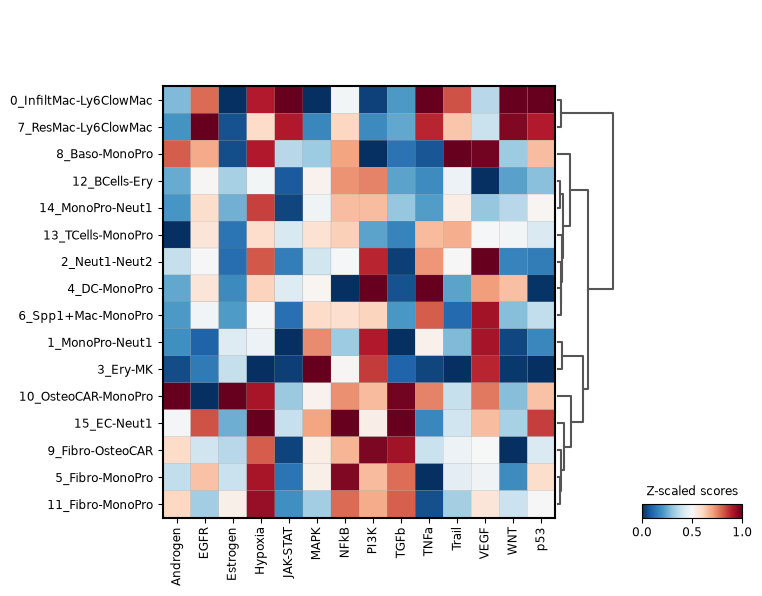

In [14]:
sc.pl.matrixplot(acts, var_names=acts.var_names, groupby='max_pair', dendrogram=True, standard_scale='var',
                 colorbar_title='Z-scaled scores', cmap='RdBu_r')

In [15]:
acts_max_pair=acts.to_df().groupby(by=acts.obs.max_pair).mean()

/tmp/ipykernel_1787996/4026765148.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  acts_max_pair=acts.to_df().groupby(by=acts.obs.max_pair).mean()


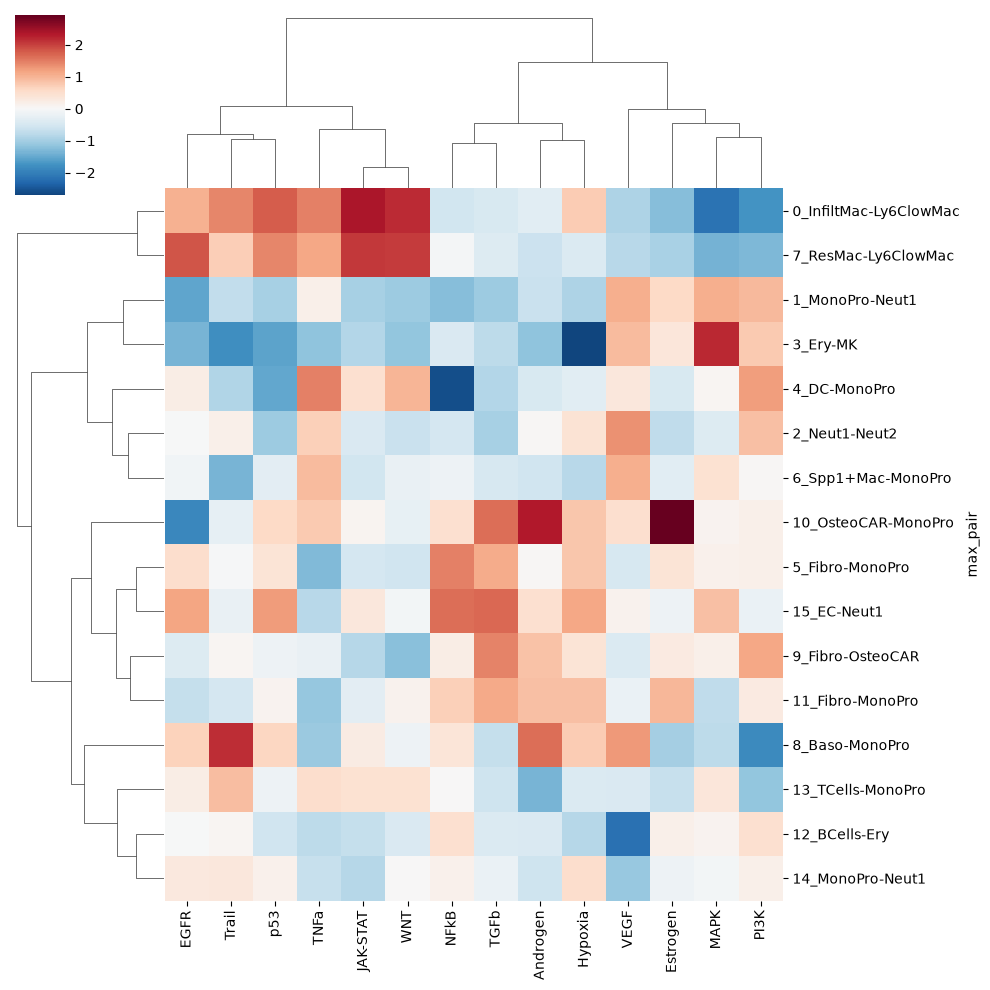

In [16]:
plot=sns.clustermap(acts_max_pair, cmap='RdBu_r', center=0, z_score=1, method='ward')

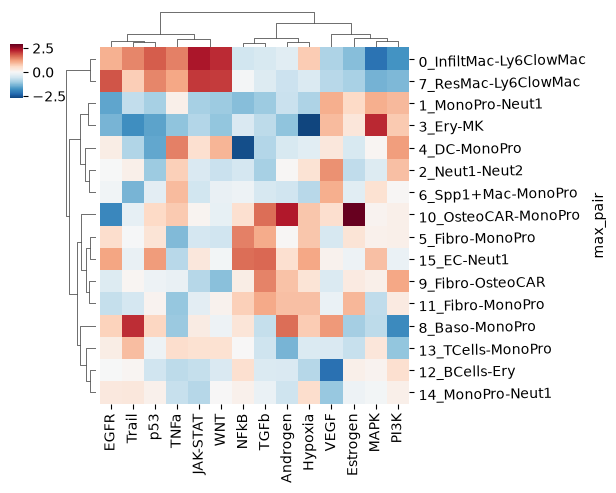

In [17]:
plot=sns.clustermap(acts_max_pair, cmap='RdBu_r', center=0, z_score=1, method='ward')
hm = plot.ax_heatmap.get_position()
plt.setp(plot.ax_heatmap.yaxis.get_majorticklabels(), fontsize=10)
plt.setp(plot.ax_heatmap.xaxis.get_majorticklabels(), fontsize=10)

## heatmap position
plot.ax_heatmap.set_position([hm.x0, hm.y0, hm.width*0.5, hm.height*0.5])
col = plot.ax_col_dendrogram.get_position()
## dendrograms position
plot.ax_col_dendrogram.set_position([col.x0, col.y0*0.55, col.width*0.5, col.height*0.25])
row = plot.ax_row_dendrogram.get_position()
plot.ax_row_dendrogram.set_position([row.x0*9, row.y0, row.width*0.2, row.height*0.5])
## colorbar position
x0, y0, w, h = plot.cbar_pos
plot.ax_cbar.set_position([x0*4, y0*0.5, w*0.25, h*0.3])
plot.figure.axes[-1].yaxis.label.set_size(10)

plt.setp(plot.ax_heatmap.yaxis.get_majorticklabels(), rotation=1)
plt.savefig('../figures/revision/F1/F1H.pdf')
plt.show()

In [18]:
### Singlets

In [19]:
dc.mt.mlm(
    data=adata_singlets,
    net=progeny, 
    verbose=True
)

2026-07-24 12:12:05 | [INFO] mlm - Running mlm
2026-07-24 12:12:05 | [INFO] Extracted omics mat with 27046 rows (observations) and 20788 columns (features)
2026-07-24 12:12:06 | [WARNING] 10 features of mat are empty, they will be removed
2026-07-24 12:12:06 | [INFO] Network adjacency matrix has 4387 unique features and 14 unique sources
100%|██████████| 1/1 [00:18<00:00, 18.46s/it]
2026-07-24 12:12:25 | [INFO] mlm - done


In [20]:
adata_singlets.obsm['progeny_mlm_estimate'] = adata_singlets.obsm['score_mlm'].copy()
adata_singlets.obsm['progeny_mlm_pvals'] = adata_singlets.obsm['padj_mlm'].copy()
adata_singlets

AnnData object with n_obs × n_vars = 27046 × 20788
    obs: 'nCount_RNA', 'nFeature_RNA', 'name', 'stage', 'percent.mt', 'percent.ribo', 'nCount_decontX', 'nFeature_decontX', 'AmbientRNA', 'decontX_clusters', 'Doublet_classifications', 'percent.exclude', 'S.Score', 'G2M.Score', 'Phase', 'G1.Score', 'CC.Difference', 'integrated_snn_res.0.1', 'integrated_snn_res.0.2', 'integrated_snn_res.0.3', 'integrated_snn_res.0.4', 'integrated_snn_res.0.5', 'integrated_snn_res.0.6', 'integrated_snn_res.0.7', 'integrated_snn_res.0.8', 'seurat_clusters', 'RNA_snn_res.0.1', 'RNA_snn_res.0.2', 'RNA_snn_res.0.3', 'RNA_snn_res.0.4', 'RNA_snn_res.0.5', 'RNA_snn_res.0.6', 'RNA_snn_res.0.7', 'RNA_snn_res.0.8', 'seurat_inte_clusters', 'harmony_inte_clusters', 'MCA_annotate', 'external_annotation', 'HCL_annotate', 'annotation', 'NABA_COLLAGENS', 'NABA_SECRETED_FACTORS', 'NABA_ECM_GLYCOPROTEINS', 'NABA_CORE_MATRISOME', 'NABA_ECM_REGULATORS', 'NABA_MATRISOME_ASSOCIATED', 'NABA_ECM_AFFILIATED', 'NABA_BASEMENT_MEMB

In [21]:
acts = dc.pp.get_obsm(adata_singlets, key="score_mlm")
acts

AnnData object with n_obs × n_vars = 27046 × 14
    obs: 'nCount_RNA', 'nFeature_RNA', 'name', 'stage', 'percent.mt', 'percent.ribo', 'nCount_decontX', 'nFeature_decontX', 'AmbientRNA', 'decontX_clusters', 'Doublet_classifications', 'percent.exclude', 'S.Score', 'G2M.Score', 'Phase', 'G1.Score', 'CC.Difference', 'integrated_snn_res.0.1', 'integrated_snn_res.0.2', 'integrated_snn_res.0.3', 'integrated_snn_res.0.4', 'integrated_snn_res.0.5', 'integrated_snn_res.0.6', 'integrated_snn_res.0.7', 'integrated_snn_res.0.8', 'seurat_clusters', 'RNA_snn_res.0.1', 'RNA_snn_res.0.2', 'RNA_snn_res.0.3', 'RNA_snn_res.0.4', 'RNA_snn_res.0.5', 'RNA_snn_res.0.6', 'RNA_snn_res.0.7', 'RNA_snn_res.0.8', 'seurat_inte_clusters', 'harmony_inte_clusters', 'MCA_annotate', 'external_annotation', 'HCL_annotate', 'annotation', 'NABA_COLLAGENS', 'NABA_SECRETED_FACTORS', 'NABA_ECM_GLYCOPROTEINS', 'NABA_CORE_MATRISOME', 'NABA_ECM_REGULATORS', 'NABA_MATRISOME_ASSOCIATED', 'NABA_ECM_AFFILIATED', 'NABA_BASEMENT_MEMBRAN

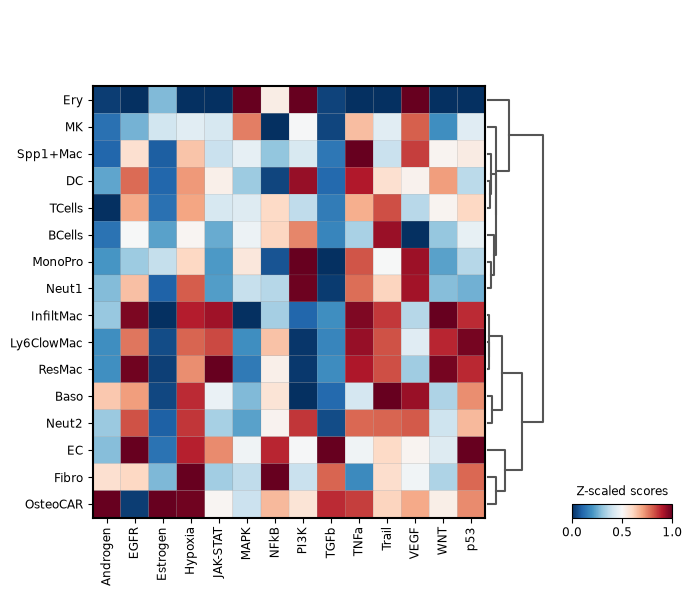

In [22]:
sc.pl.matrixplot(acts, var_names=acts.var_names, groupby='annotation', dendrogram=True, standard_scale='var',
                 colorbar_title='Z-scaled scores', cmap='RdBu_r')

In [23]:
acts_max_pair=acts.to_df().groupby(by=acts.obs.annotation).mean()

/tmp/ipykernel_1787996/1624593468.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  acts_max_pair=acts.to_df().groupby(by=acts.obs.annotation).mean()


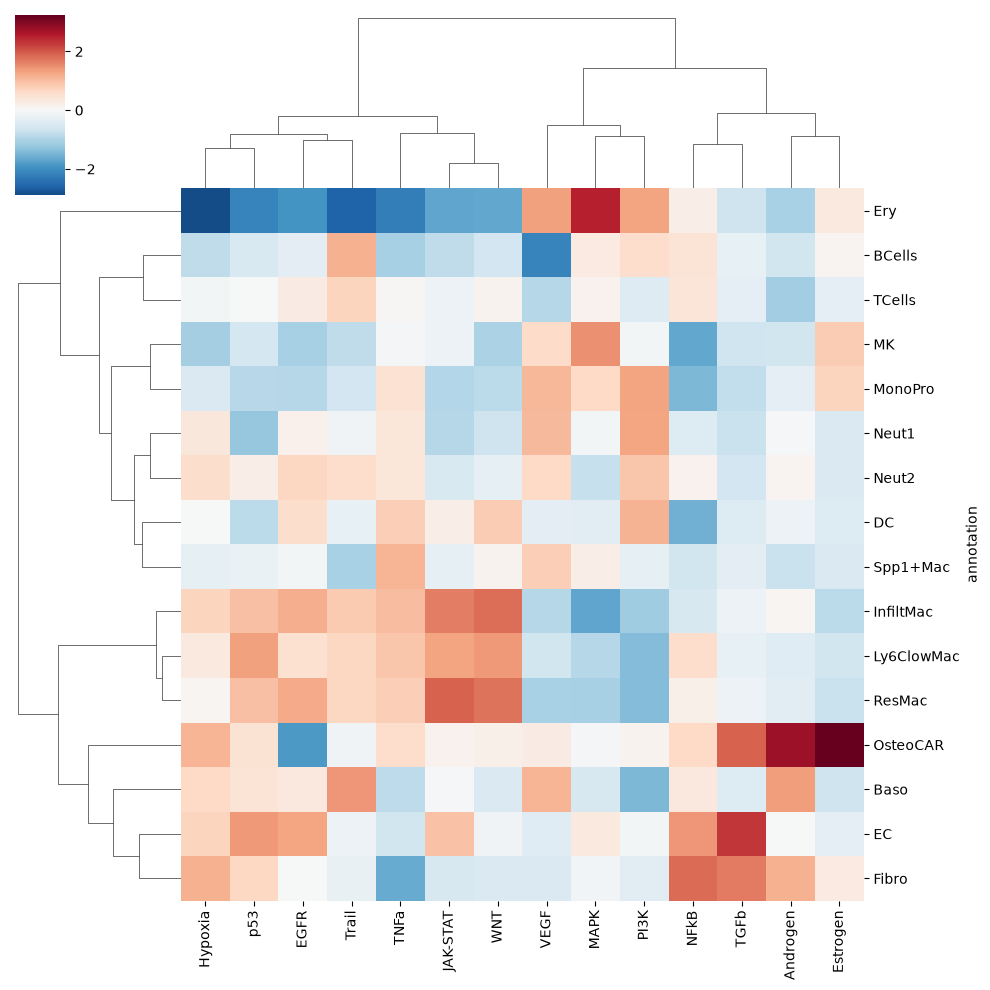

In [24]:
plot=sns.clustermap(acts_max_pair, cmap='RdBu_r', center=0, z_score=1, method='ward')

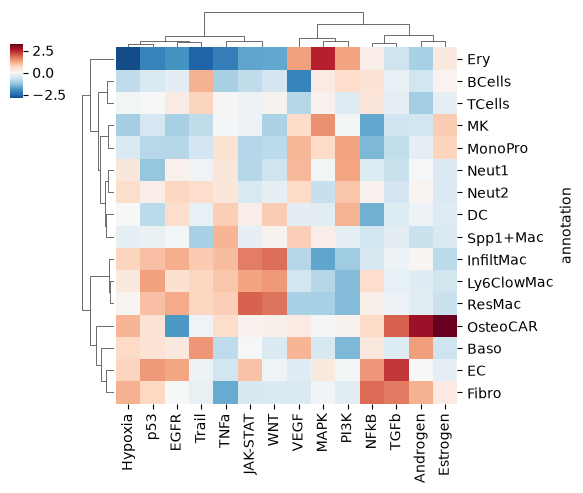

In [25]:
plot=sns.clustermap(acts_max_pair, cmap='RdBu_r', center=0, z_score=1, method='ward')
hm = plot.ax_heatmap.get_position()
plt.setp(plot.ax_heatmap.yaxis.get_majorticklabels(), fontsize=10)
plt.setp(plot.ax_heatmap.xaxis.get_majorticklabels(), fontsize=10)

## heatmap position
plot.ax_heatmap.set_position([hm.x0, hm.y0, hm.width*0.5, hm.height*0.5])
col = plot.ax_col_dendrogram.get_position()
## dendrograms position
plot.ax_col_dendrogram.set_position([col.x0, col.y0*0.55, col.width*0.5, col.height*0.25])
row = plot.ax_row_dendrogram.get_position()
plot.ax_row_dendrogram.set_position([row.x0*10, row.y0, row.width*0.2, row.height*0.5])
## colorbar position
x0, y0, w, h = plot.cbar_pos
plot.ax_cbar.set_position([x0*4, y0*0.5, w*0.25, h*0.3])
plot.figure.axes[-1].yaxis.label.set_size(10)

plt.setp(plot.ax_heatmap.yaxis.get_majorticklabels(), rotation=1)
plt.savefig('../figures/revision/F1/F1E.pdf')
plt.show()

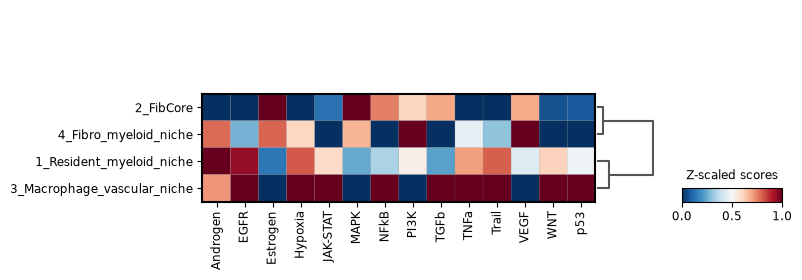

In [26]:
sc.pl.matrixplot(acts, var_names=acts.var_names, groupby='niche', dendrogram=True, standard_scale='var',
                 colorbar_title='Z-scaled scores', cmap='RdBu_r')

In [27]:
acts_max_pair=acts.to_df().groupby(by=acts.obs.niche).mean()

/tmp/ipykernel_1787996/2648209025.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  acts_max_pair=acts.to_df().groupby(by=acts.obs.niche).mean()


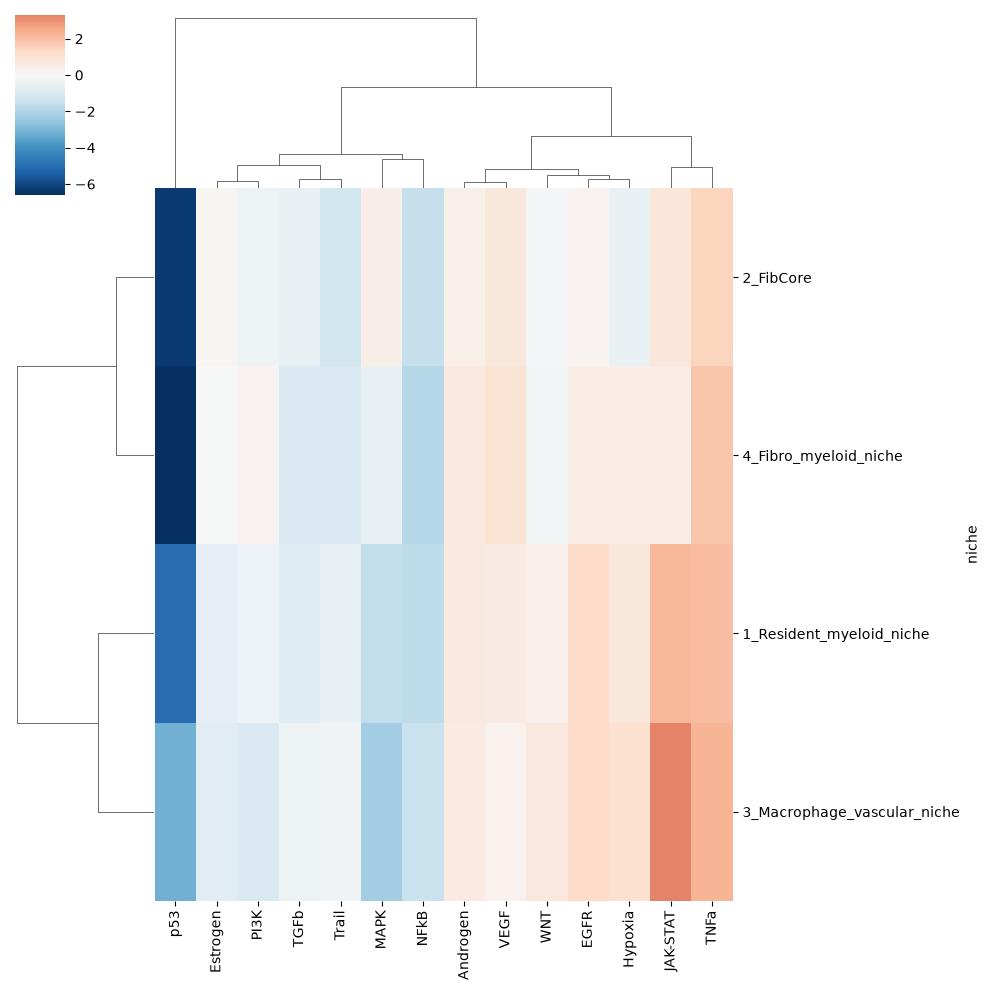

In [28]:
plot=sns.clustermap(acts_max_pair, cmap='RdBu_r', center=0, method='ward')

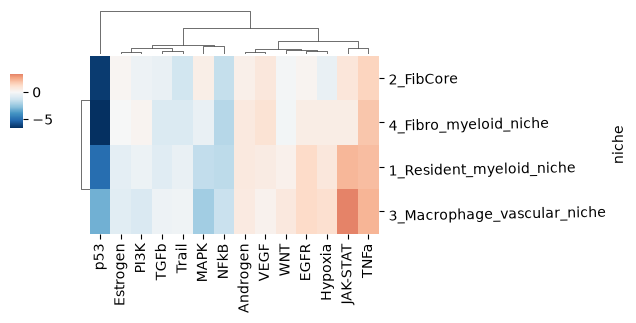

In [29]:
plot=sns.clustermap(acts_max_pair, cmap='RdBu_r', center=0, method='ward')
hm = plot.ax_heatmap.get_position()
plt.setp(plot.ax_heatmap.yaxis.get_majorticklabels(), fontsize=10)
plt.setp(plot.ax_heatmap.xaxis.get_majorticklabels(), fontsize=10)

## heatmap position
plot.ax_heatmap.set_position([hm.x0, hm.y0, hm.width*0.5, hm.height*0.25])
col = plot.ax_col_dendrogram.get_position()
## dendrograms position
plot.ax_col_dendrogram.set_position([col.x0, col.y0*0.34, col.width*0.5, col.height*0.25])
row = plot.ax_row_dendrogram.get_position()
plot.ax_row_dendrogram.set_position([row.x0*10, row.y0, row.width*0.2, row.height*0.25])
## colorbar position
x0, y0, w, h = plot.cbar_pos
plot.ax_cbar.set_position([x0*4, y0*0.25, w*0.25, h*0.3])
plot.figure.axes[-1].yaxis.label.set_size(10)

plt.setp(plot.ax_heatmap.yaxis.get_majorticklabels(), rotation=1)
#plt.savefig('../figures/revision/progeny_singlets_niche.pdf')
plt.show()

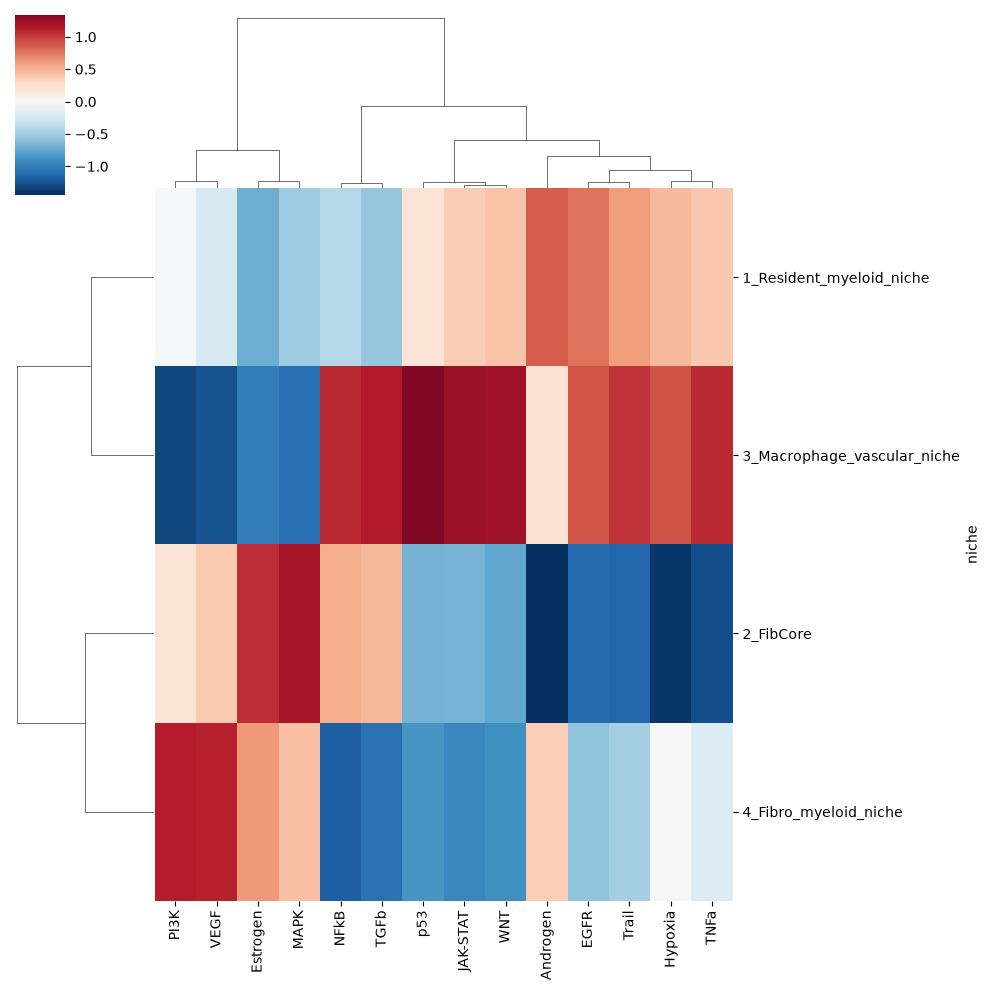

In [30]:
plot=sns.clustermap(acts_max_pair, cmap='RdBu_r', center=0, method='ward', z_score=1)

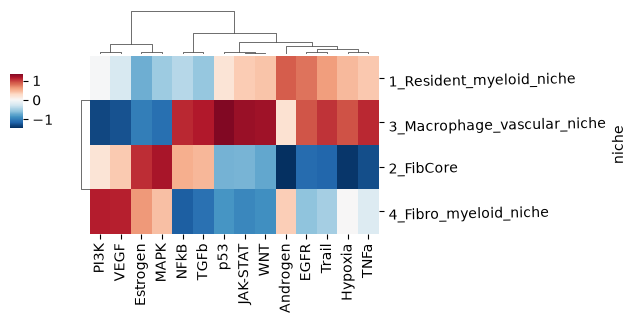

In [31]:
plot=sns.clustermap(acts_max_pair, cmap='RdBu_r', center=0, method='ward', z_score=1)
hm = plot.ax_heatmap.get_position()
plt.setp(plot.ax_heatmap.yaxis.get_majorticklabels(), fontsize=10)
plt.setp(plot.ax_heatmap.xaxis.get_majorticklabels(), fontsize=10)

## heatmap position
plot.ax_heatmap.set_position([hm.x0, hm.y0, hm.width*0.5, hm.height*0.25])
col = plot.ax_col_dendrogram.get_position()
## dendrograms position
plot.ax_col_dendrogram.set_position([col.x0, col.y0*0.34, col.width*0.5, col.height*0.25])
row = plot.ax_row_dendrogram.get_position()
plot.ax_row_dendrogram.set_position([row.x0*10, row.y0, row.width*0.2, row.height*0.25])
## colorbar position
x0, y0, w, h = plot.cbar_pos
plot.ax_cbar.set_position([x0*4, y0*0.25, w*0.25, h*0.3])
plot.figure.axes[-1].yaxis.label.set_size(10)

plt.setp(plot.ax_heatmap.yaxis.get_majorticklabels(), rotation=1)
plt.savefig('../figures/revision/F2/F2C.pdf')
plt.show()